# Ringdown Measurement Analysis
Analysis of YAW monitor output data to extract damping parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import h5py
from datetime import datetime, timedelta, timezone
from scipy.signal import welch
from scipy.optimize import curve_fit

In [2]:
filename = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250801/Y1_RDS-LES_YAW_MON_OUT_DQ_1437819028_1438164628.h5'

## 1. Explore HDF5 Structure

In [3]:
with h5py.File(filename, 'r') as f:
    print("=== HDF5 File Structure ===")
    print(f"Top-level keys: {list(f.keys())}")
    print(f"\nRoot attributes: {dict(f.attrs)}")
    print(f"\nSegments keys: {list(f['segments'].keys())}")
    print(f"\nData shape: {f['data'].shape}")
    print(f"Data dtype: {f['data'].dtype}")

=== HDF5 File Structure ===
Top-level keys: ['data', 'segments']

Root attributes: {'channel': 'Y1:RDS-LES_YAW_MON_OUT_DQ', 'created_utc': '2025-08-19T14:57:58Z', 'gps_end': 1438164628, 'gps_start': 1437819028, 'sample_rate': 1024.0}

Segments keys: ['gps_start', 'index_start', 'length']

Data shape: (353861632,)
Data dtype: float32


## 2. Load Data

In [4]:
# GPS to Unix offset (includes leap seconds correction)
GPS_UNIX_OFFSET = 315964800 - 18

def gps_to_datetime(gps_time):
    """Convert GPS time to UTC datetime"""
    return datetime.fromtimestamp(gps_time + GPS_UNIX_OFFSET, tz=timezone.utc)

In [5]:
# Load file metadata and segment info
with h5py.File(filename, 'r') as f:
    sample_rate = float(f.attrs['sample_rate'])
    gps_start_file = f.attrs['gps_start']
    gps_end_file = f.attrs['gps_end']
    
    segment_starts = f['segments/index_start'][:]
    segment_lengths = f['segments/length'][:]
    segment_gps_times = f['segments/gps_start'][:]
    
    total_samples = f['data'].shape[0]

dt = 1.0 / sample_rate

print(f"Sample rate: {sample_rate} Hz")
print(f"Total samples: {total_samples:,}")
print(f"Duration: {total_samples / sample_rate / 3600:.2f} hours")
print(f"Number of segments: {len(segment_starts)}")
print(f"\nTime range:")
print(f"  Start: {gps_to_datetime(gps_start_file)}")
print(f"  End: {gps_to_datetime(gps_end_file)}")

Sample rate: 1024.0 Hz
Total samples: 353,861,632
Duration: 95.99 hours
Number of segments: 578

Time range:
  Start: 2025-07-29 10:10:10+00:00
  End: 2025-08-02 10:10:10+00:00


## 3. Raw Time Series Data (Downsampled for Plotting)

In [6]:
# Downsample for plotting to avoid memory issues
max_plot_points = 200000

t_plot = []
y_plot = []

with h5py.File(filename, 'r') as f:
    data = f['data']
    step = max(1, total_samples // max_plot_points)
    
    print(f"Decimation step: {step}")
    
    for i in range(len(segment_starts)):
        start = int(segment_starts[i])
        n = int(segment_lengths[i])
        if n <= 0:
            continue
        
        # Align sampling to maintain consistency
        r = (-start) % step
        seg_indices = np.arange(start + r, start + n, step, dtype=np.int64)
        if seg_indices.size == 0:
            continue
        
        y_seg = data[seg_indices]
        t_seg = segment_gps_times[i] + (seg_indices - start).astype(np.float64) * dt
        
        t_datetime = [gps_to_datetime(tt) for tt in t_seg]
        
        t_plot.extend(t_datetime)
        y_plot.extend(y_seg)

t_plot = np.array(t_plot)
y_plot = np.array(y_plot)
print(f"Downsampled to {len(y_plot):,} points")

Decimation step: 1769
Downsampled to 200,035 points


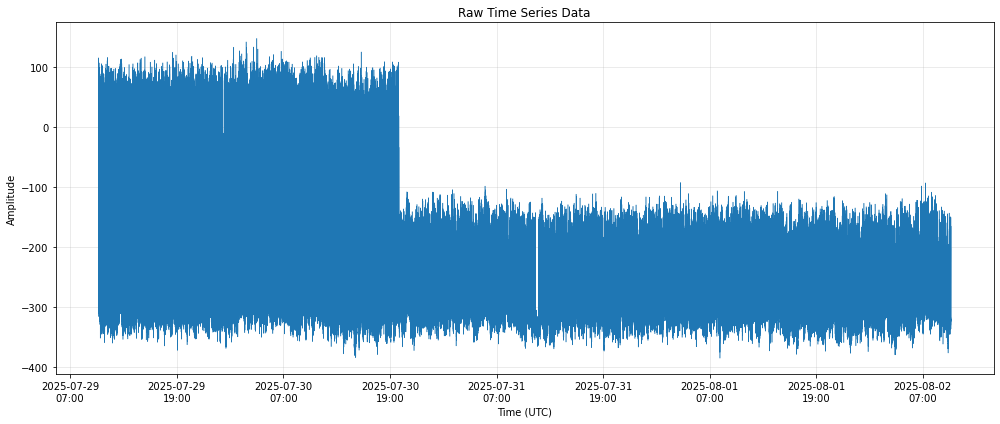

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(t_plot, y_plot, linewidth=0.5)
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('Amplitude')
ax.set_title('Raw Time Series Data')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Dominant Peak Frequency Over Time
Using 20-second FFT windows for 0.05 Hz frequency resolution

In [8]:
# FFT Parameters
win_sec = 20.0  # Window duration in seconds (gives 0.05 Hz resolution)
overlap = 0.5   # 50% overlap
band = (0.1, 2.0)  # Frequency band of interest (Hz)

N = int(round(win_sec * sample_rate))  # Samples per window
step_fft = max(1, int(round(N * (1.0 - overlap))))  # Hop size
window = np.hanning(N).astype(np.float64)

# FFT frequency axis
freqs = np.fft.rfftfreq(N, d=dt)
fmin, fmax = band
band_mask = (freqs >= fmin) & (freqs <= fmax)
freqs_band = freqs[band_mask]

print(f"Window: {win_sec} s ({N} samples)")
print(f"Frequency resolution: {1.0/win_sec} Hz")
print(f"Hop: {step_fft} samples ({step_fft/sample_rate:.1f} s)")
print(f"Band: {fmin} - {fmax} Hz ({np.sum(band_mask)} bins)")

Window: 20.0 s (20480 samples)
Frequency resolution: 0.05 Hz
Hop: 10240 samples (10.0 s)
Band: 0.1 - 2.0 Hz (39 bins)


In [9]:
# Sort segments by time
order = np.argsort(segment_gps_times)
idx_sorted = segment_starts[order].astype(np.int64)
length_sorted = segment_lengths[order].astype(np.int64)
t0_sorted = segment_gps_times[order].astype(np.float64)

In [10]:
# Compute dominant frequency in sliding windows with PARABOLIC INTERPOLATION
# This gives sub-bin frequency resolution for smooth tracking

def parabolic_interp(psd, peak_idx):
    """
    Parabolic interpolation around a peak to get sub-bin frequency accuracy.
    Returns the fractional bin offset from peak_idx.
    """
    if peak_idx == 0 or peak_idx >= len(psd) - 1:
        return 0.0
    
    alpha = psd[peak_idx - 1]
    beta = psd[peak_idx]
    gamma = psd[peak_idx + 1]
    
    # Avoid division by zero
    denom = alpha - 2*beta + gamma
    if abs(denom) < 1e-10:
        return 0.0
    
    # Parabolic interpolation formula
    offset = 0.5 * (alpha - gamma) / denom
    return offset

t_freq = []  # Window center times (datetime)
f_dom = []   # Dominant frequencies (with interpolation)

# Frequency resolution
df = 1.0 / win_sec  # Hz per bin

with h5py.File(filename, 'r') as f:
    data = f['data']
    
    for seg_i, seg_n, seg_t0 in zip(idx_sorted, length_sorted, t0_sorted):
        if seg_n < N:
            continue
        
        # Process windows within this segment
        for j in range(0, seg_n - N + 1, step_fft):
            chunk = data[seg_i + j : seg_i + j + N].astype(np.float64)
            
            # Skip if contains NaN
            if np.isnan(chunk).any():
                continue
            
            # Apply window and remove DC
            chunk = (chunk - np.mean(chunk)) * window
            
            # Compute PSD
            fft_result = np.fft.rfft(chunk)
            psd = np.abs(fft_result) ** 2
            psd_band = psd[band_mask]
            
            if psd_band.size == 0:
                continue
            
            # Find peak in band
            peak_idx_band = np.argmax(psd_band)
            
            # Get the actual index in the full PSD array
            band_indices = np.where(band_mask)[0]
            peak_idx_full = band_indices[peak_idx_band]
            
            # Parabolic interpolation for sub-bin accuracy
            offset = parabolic_interp(psd, peak_idx_full)
            
            # Interpolated frequency
            dom_freq = (peak_idx_full + offset) * df
            
            # Window center time
            t_center_gps = seg_t0 + (j + N / 2) * dt
            t_center = gps_to_datetime(t_center_gps)
            
            t_freq.append(t_center)
            f_dom.append(dom_freq)

t_freq = np.array(t_freq)
f_dom = np.array(f_dom)
print(f"Computed {len(f_dom)} frequency measurements")

Computed 33977 frequency measurements


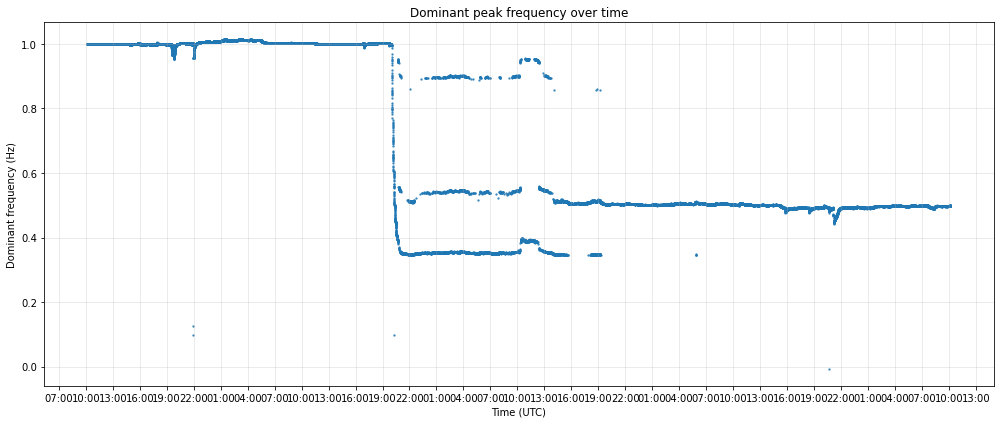

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(t_freq, f_dom, s=2, alpha=0.7)
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('Dominant frequency (Hz)')
ax.set_title('Dominant peak frequency over time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Select Ringdown Region

In [12]:
# Print time range to help select ringdown region
print("Time range of frequency data:")
print(f"  Start: {t_freq[0]}")
print(f"  End: {t_freq[-1]}")
print(f"\nFrequency range: {f_dom.min():.3f} - {f_dom.max():.3f} Hz")

Time range of frequency data:
  Start: 2025-07-29 10:10:20+00:00
  End: 2025-08-02 10:10:00+00:00

Frequency range: -0.008 - 1.015 Hz


In [13]:
# Extend time window to show full decay and steady-state
ringdown_start = datetime(2025, 7, 30, 19, 46, 0, tzinfo=timezone.utc)
ringdown_end = datetime(2025, 7, 30, 21, 20, 0, tzinfo=timezone.utc)

# Filter to ringdown region
mask_time = (t_freq >= ringdown_start) & (t_freq <= ringdown_end)

t_ringdown = t_freq[mask_time]
f_ringdown = f_dom[mask_time]

print(f"Ringdown region: {len(f_ringdown)} points")
print(f"From {ringdown_start} to {ringdown_end}")

Ringdown region: 556 points
From 2025-07-30 19:46:00+00:00 to 2025-07-30 21:20:00+00:00


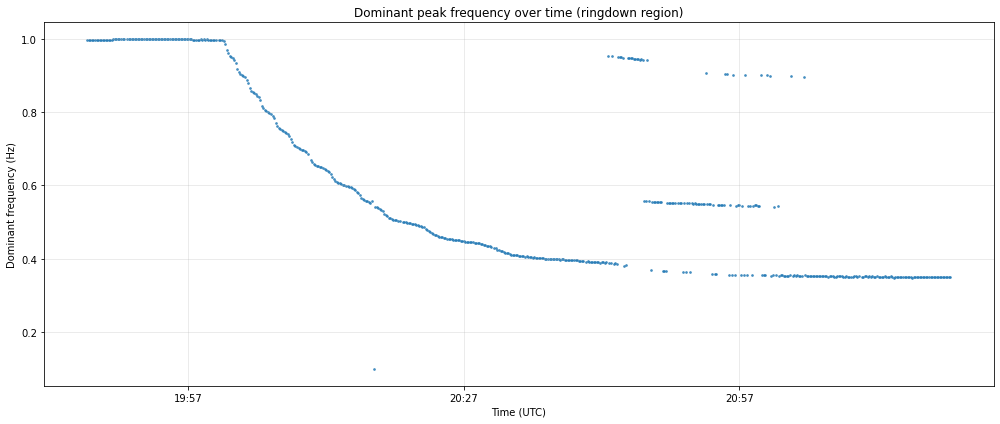

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(t_ringdown, f_ringdown, s=3, alpha=0.7)
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('Dominant frequency (Hz)')
ax.set_title('Dominant peak frequency over time (ringdown region)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Remove Artifacts (Filter Non-Dominant Curves)

In [15]:
def filter_artifacts(freqs, times):
    """
    Remove artifact branches that appear after a certain time.
    After ~20:36 UTC, only keep the LOW frequency branch (the real decay/steady-state).
    Remove the higher frequency artifact branches (~0.55 Hz, ~0.9 Hz).
    """
    n = len(freqs)
    valid = np.ones(n, dtype=bool)
    
    # Define the cutoff time after which artifacts appear
    artifact_start_time = datetime(2025, 7, 30, 20, 36, 0, tzinfo=timezone.utc)
    
    # After this time, only keep frequencies below this threshold (the real steady-state branch)
    max_freq_after_cutoff = 0.45  # Hz - the real data stays below this
    
    for i in range(n):
        # After the cutoff time, remove high frequency points (artifact branches)
        if times[i] > artifact_start_time and freqs[i] > max_freq_after_cutoff:
            valid[i] = False
        
        # Also remove obvious outliers (very low frequencies)
        if freqs[i] < 0.15:
            valid[i] = False
    
    return valid

# Apply filtering
valid_mask = filter_artifacts(f_ringdown, t_ringdown)

t_clean = t_ringdown[valid_mask]
f_clean = f_ringdown[valid_mask]

print(f"After filtering: {len(f_clean)} points (removed {len(f_ringdown) - len(f_clean)})")

After filtering: 473 points (removed 83)


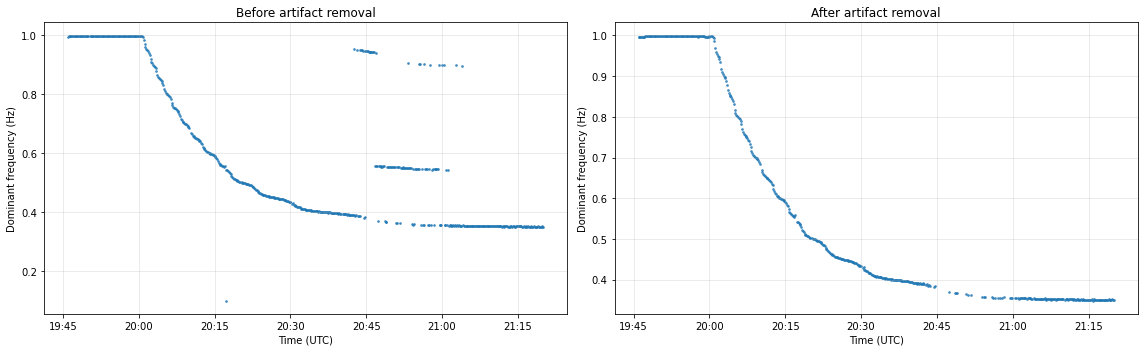

In [16]:
# Compare before and after filtering
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(t_ringdown, f_ringdown, s=3, alpha=0.7)
axes[0].set_xlabel('Time (UTC)')
axes[0].set_ylabel('Dominant frequency (Hz)')
axes[0].set_title('Before artifact removal')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[0].grid(True, alpha=0.3)

axes[1].scatter(t_clean, f_clean, s=3, alpha=0.7)
axes[1].set_xlabel('Time (UTC)')
axes[1].set_ylabel('Dominant frequency (Hz)')
axes[1].set_title('After artifact removal')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Plot saved to: /Users/mollywatts/Downloads/after_artifact_removal.png


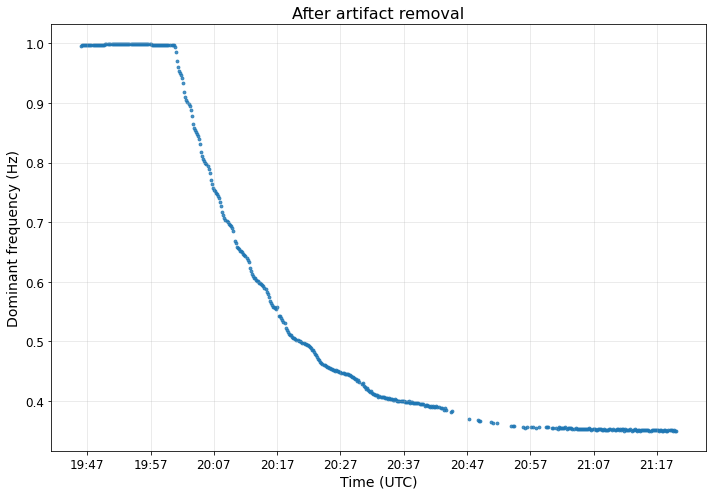

In [17]:
# Save a clean plot for poster - "After artifact removal"
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(t_clean, f_clean, s=8, alpha=0.8)
ax.set_xlabel('Time (UTC)', fontsize=14)
ax.set_ylabel('Dominant frequency (Hz)', fontsize=14)
ax.set_title('After artifact removal', fontsize=16)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
ax.tick_params(axis='both', labelsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save to Downloads folder
save_path = '/Users/mollywatts/Downloads/after_artifact_removal.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Plot saved to: {save_path}")

plt.show()

## 7. Damping Measurement
Fit ln(ω - ω_ss) vs time to extract damping constant

In [18]:
# Convert frequency to angular frequency
omega = 2 * np.pi * f_clean  # rad/s

# Estimate steady-state frequency from the last portion
omega_ss = np.median(omega[-len(omega)//10:]) if len(omega) > 10 else omega[-1]
freq_ss = omega_ss / (2 * np.pi)

print(f"Estimated steady-state frequency: {freq_ss:.4f} Hz ({omega_ss:.4f} rad/s)")

# You can override this if needed:
# omega_ss = 2 * np.pi * 0.35  # e.g., 0.35 Hz

Estimated steady-state frequency: 0.3507 Hz (2.2035 rad/s)


In [19]:
# Select only the DECAYING portion:
# - Exclude the flat 1.0 Hz plateau at the start (freq > 0.95 Hz)
# - Exclude the noisy tail where freq is too close to omega_ss
# - Only keep the clean exponential decay region

omega = 2 * np.pi * f_clean  # rad/s

# Estimate steady-state from the data
omega_ss = np.median(omega[-len(omega)//10:]) if len(omega) > 10 else omega[-1]
freq_ss = omega_ss / (2 * np.pi)
print(f"Estimated steady-state frequency: {freq_ss:.4f} Hz ({omega_ss:.4f} rad/s)")

# Define the decay region:
# - Upper bound: below 0.95 Hz (exclude the 1.0 Hz plateau)
# - Lower bound: above omega_ss * 1.10 (exclude noisy tail near steady-state)
freq_clean_arr = f_clean

upper_freq_limit = 0.95  # Hz - below this, decay has started
lower_freq_limit = freq_ss * 1.10  # Hz - above this, not too close to steady-state

decay_mask = (freq_clean_arr < upper_freq_limit) & (freq_clean_arr > lower_freq_limit)

omega_decay = omega[decay_mask]
t_decay = t_clean[decay_mask]

if len(omega_decay) < 10:
    print("WARNING: Not enough points in decay region. Adjust limits.")
else:
    # Convert datetime to seconds from start
    t_seconds = np.array([(t - t_decay[0]).total_seconds() for t in t_decay])
    
    # Compute ln(omega - omega_ss)
    ln_omega_diff = np.log(omega_decay - omega_ss)
    
    print(f"Decay region: {len(omega_decay)} points")
    print(f"Frequency range: {freq_clean_arr[decay_mask].max():.3f} - {freq_clean_arr[decay_mask].min():.3f} Hz")
    print(f"Time span: {t_seconds[-1]:.1f} seconds ({t_seconds[-1]/60:.1f} minutes)")

Estimated steady-state frequency: 0.3507 Hz (2.2035 rad/s)
Decay region: 243 points
Frequency range: 0.947 - 0.388 Hz
Time span: 2500.0 seconds (41.7 minutes)


In [20]:
# Linear fit: ln(omega - omega_ss) = ln(A) - gamma * t
def linear_fit(t, ln_A, gamma):
    return ln_A - gamma * t

if len(omega_decay) >= 10:
    popt, pcov = curve_fit(linear_fit, t_seconds, ln_omega_diff)
    ln_A, gamma = popt
    ln_A_err, gamma_err = np.sqrt(np.diag(pcov))
    
    tau = 1.0 / gamma
    tau_err = gamma_err / (gamma**2)
    
    print(f"\n=== Damping Fit Results ===")
    print(f"Damping constant: γ = {gamma:.6f} ± {gamma_err:.6f} 1/s")
    print(f"Damping time: τ = {tau:.1f} ± {tau_err:.1f} s ({tau/60:.2f} ± {tau_err/60:.2f} minutes)")
    print(f"Initial amplitude: A = {np.exp(ln_A):.4f} rad/s")


=== Damping Fit Results ===
Damping constant: γ = 0.001166 ± 0.000005 1/s
Damping time: τ = 857.3 ± 3.9 s (14.29 ± 0.06 minutes)
Initial amplitude: A = 3.6097 rad/s


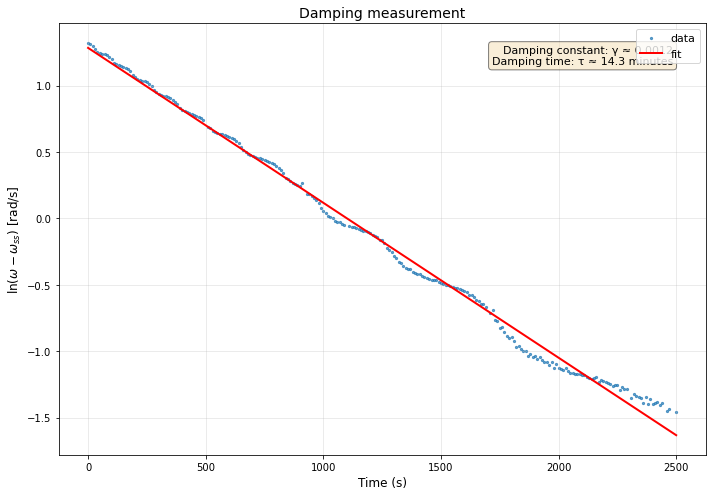

In [21]:
# Plot damping measurement
if len(omega_decay) >= 10:
    fig, ax = plt.subplots(figsize=(10, 7))
    
    ax.scatter(t_seconds, ln_omega_diff, s=5, alpha=0.7, label='data')
    
    t_fit = np.linspace(t_seconds[0], t_seconds[-1], 100)
    ax.plot(t_fit, linear_fit(t_fit, ln_A, gamma), 'r-', linewidth=2, label='fit')
    
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel(r'ln($\omega - \omega_{ss}$) [rad/s]', fontsize=12)
    ax.set_title('Damping measurement', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    textstr = f'Damping constant: γ ≈ {gamma:.4f}\nDamping time: τ ≈ {tau/60:.1f} minutes'
    ax.text(0.95, 0.95, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

Plot saved to: /Users/mollywatts/Downloads/damping_measurement_clean.png


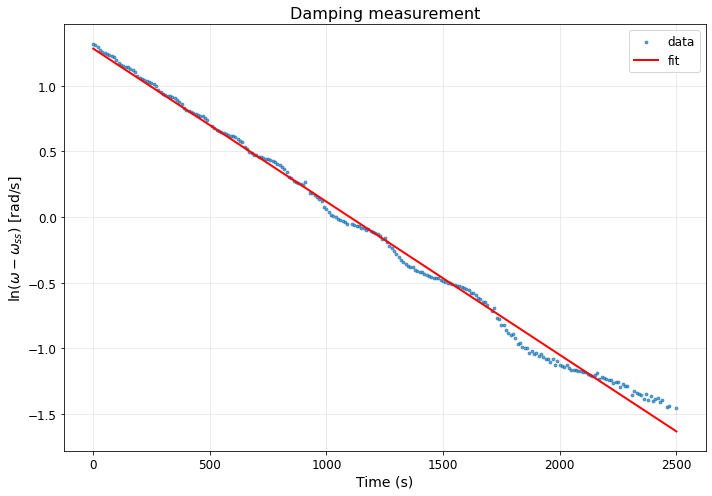

In [22]:
# Save damping fit plot for poster - clean version
if len(omega_decay) >= 10:
    fig, ax = plt.subplots(figsize=(10, 7))
    
    ax.scatter(t_seconds, ln_omega_diff, s=8, alpha=0.7, label='data')
    
    t_fit = np.linspace(t_seconds[0], t_seconds[-1], 100)
    ax.plot(t_fit, linear_fit(t_fit, ln_A, gamma), 'r-', linewidth=2, label='fit')
    
    ax.set_xlabel('Time (s)', fontsize=14)
    ax.set_ylabel(r'ln($\omega - \omega_{ss}$) [rad/s]', fontsize=14)
    ax.set_title('Damping measurement', fontsize=16)
    ax.legend(fontsize=12, loc='upper right')
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    save_path = '/Users/mollywatts/Downloads/damping_measurement_clean.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Plot saved to: {save_path}")
    
    plt.show()

Plot saved to: /Users/mollywatts/Downloads/frequency_exponential_fit_clean.png


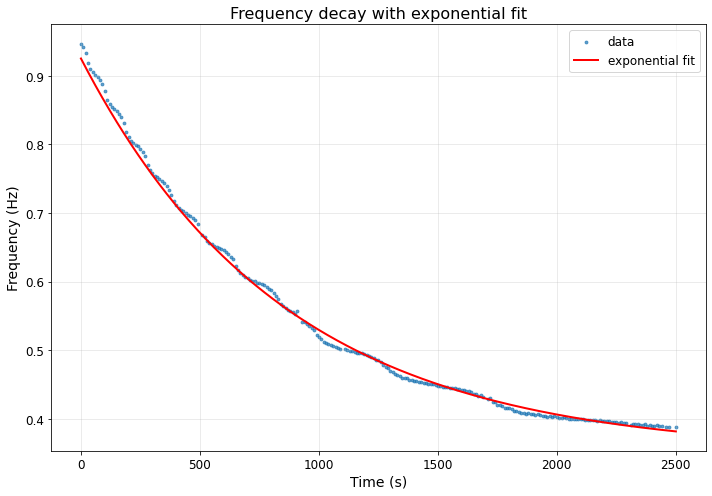

In [23]:
# Plot frequency vs time with exponential fit overlaid - NO text box version
# f(t) = f_ss + A * exp(-gamma * t)

# Use the decay region data (same as used for the linear fit)
t_decay_seconds = np.array([(t - t_decay[0]).total_seconds() for t in t_decay])
f_decay = omega_decay / (2 * np.pi)  # Convert back to Hz

# Exponential fit parameters
A_freq = np.exp(ln_A) / (2 * np.pi)  # Amplitude in Hz

# Generate fit curve
t_fit_exp = np.linspace(t_decay_seconds[0], t_decay_seconds[-1], 500)
f_fit_exp = freq_ss + A_freq * np.exp(-gamma * t_fit_exp)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(t_decay_seconds, f_decay, s=8, alpha=0.7, label='data')
ax.plot(t_fit_exp, f_fit_exp, 'r-', linewidth=2, label='exponential fit')

ax.set_xlabel('Time (s)', fontsize=14)
ax.set_ylabel('Frequency (Hz)', fontsize=14)
ax.set_title('Frequency decay with exponential fit', fontsize=16)
ax.legend(fontsize=12, loc='upper right')
ax.tick_params(axis='both', labelsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()

save_path = '/Users/mollywatts/Downloads/frequency_exponential_fit_clean.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Plot saved to: {save_path}")

plt.show()

Plot saved to: /Users/mollywatts/Downloads/frequency_exponential_fit_full_data.png


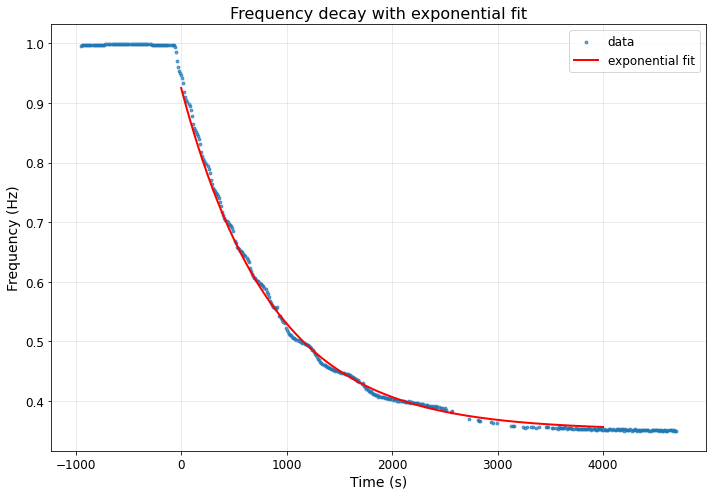

In [24]:
# Plot FULL cleaned data with exponential fit extended to 4000s
# Shows the full time stream with fit covering more of the decay

# Full cleaned data - convert to seconds from start of decay
t0_decay = t_decay[0]  # Reference time (start of decay region)
t_clean_seconds = np.array([(t - t0_decay).total_seconds() for t in t_clean])
f_clean_hz = f_clean  # Already in Hz

# Exponential fit parameters (same as before)
A_freq = np.exp(ln_A) / (2 * np.pi)  # Amplitude in Hz

# Generate fit curve - extended to 4000 seconds
t_fit_exp = np.linspace(0, 4000, 500)
f_fit_exp = freq_ss + A_freq * np.exp(-gamma * t_fit_exp)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

# Plot ALL cleaned data
ax.scatter(t_clean_seconds, f_clean_hz, s=8, alpha=0.7, label='data')

# Plot fit extended to 4000s
ax.plot(t_fit_exp, f_fit_exp, 'r-', linewidth=2, label='exponential fit')

ax.set_xlabel('Time (s)', fontsize=14)
ax.set_ylabel('Frequency (Hz)', fontsize=14)
ax.set_title('Frequency decay with exponential fit', fontsize=16)
ax.legend(fontsize=12, loc='upper right')
ax.tick_params(axis='both', labelsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()

save_path = '/Users/mollywatts/Downloads/frequency_exponential_fit_full_data.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Plot saved to: {save_path}")

plt.show()

## 8. Summary Plots

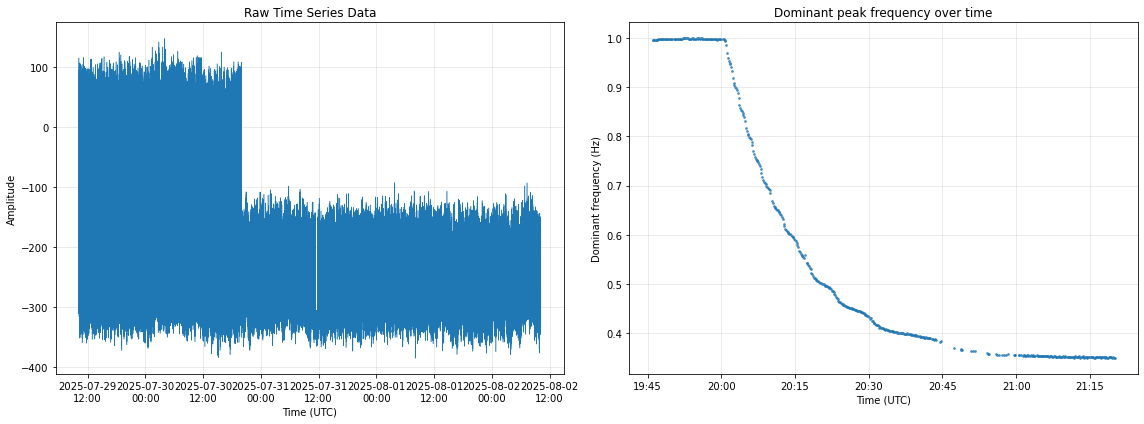

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Raw time series
axes[0].plot(t_plot, y_plot, linewidth=0.5)
axes[0].set_xlabel('Time (UTC)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Raw Time Series Data')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M'))
axes[0].grid(True, alpha=0.3)

# Right: Cleaned frequency track
axes[1].scatter(t_clean, f_clean, s=3, alpha=0.7)
axes[1].set_xlabel('Time (UTC)')
axes[1].set_ylabel('Dominant frequency (Hz)')
axes[1].set_title('Dominant peak frequency over time')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Results Summary

In [26]:
if len(omega_decay) >= 10:
    print("=== Final Results ===")
    print(f"Damping constant (γ): {gamma:.6f} ± {gamma_err:.6f} 1/s")
    print(f"Damping time (τ): {tau:.1f} ± {tau_err:.1f} s")
    print(f"Damping time (τ): {tau/60:.2f} ± {tau_err/60:.2f} minutes")
    print(f"Steady-state frequency: {freq_ss:.4f} Hz")
else:
    print("Insufficient data for damping fit. Adjust parameters.")

=== Final Results ===
Damping constant (γ): 0.001166 ± 0.000005 1/s
Damping time (τ): 857.3 ± 3.9 s
Damping time (τ): 14.29 ± 0.06 minutes
Steady-state frequency: 0.3507 Hz
